<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula04a_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## O que é Regressão?
- Problema de regressão: prever uma variável contínua a partir de uma ou mais variáveis explicativas.  
- Exemplo: prever o preço mediano de casas a partir de renda média, idade das casas, número médio de cômodos etc.
- Saída típica: $\hat{y} \in \mathbb{R}$ (não rótulos categóricos).  

## California Housing Dataset
- Dataset: California Housing, com 20.640 amostras e 8 atributos explicativos.   
- Atributos principais: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude.
- Alvo: valor mediano das casas em unidades de 100.000 dólares.


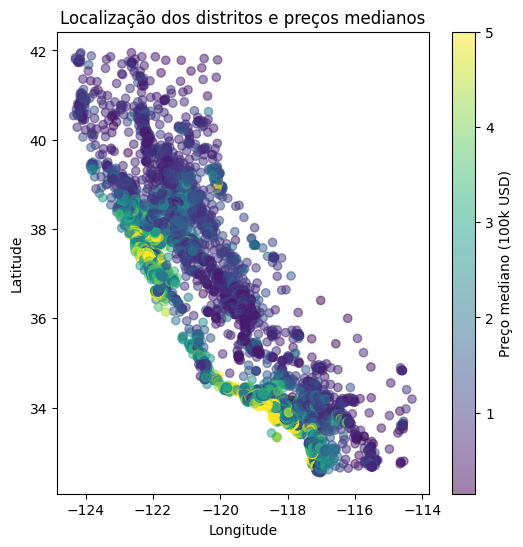

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

plt.figure(figsize=(6, 6))
plt.scatter(X[:, feature_names.index("Longitude")],
            X[:, feature_names.index("Latitude")],
            c=y, cmap="viridis", alpha=0.5)
plt.colorbar(label="Preço mediano (100k USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Localização dos distritos e preços medianos")
plt.show()

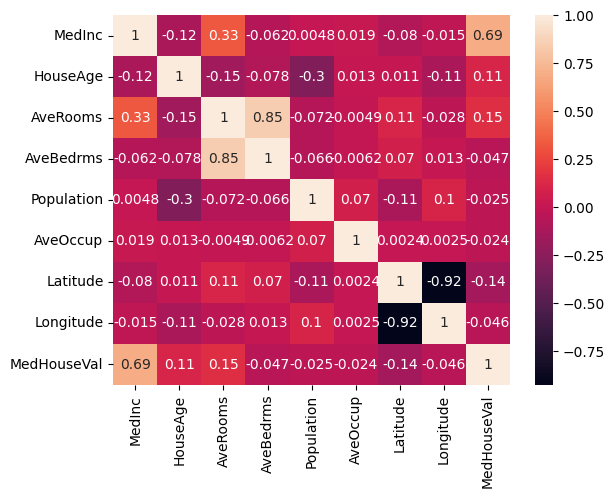

In [7]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(X, columns=feature_names)
df["MedHouseVal"] = y
corr = df.corr()
_ = sns.heatmap(corr, annot=True)

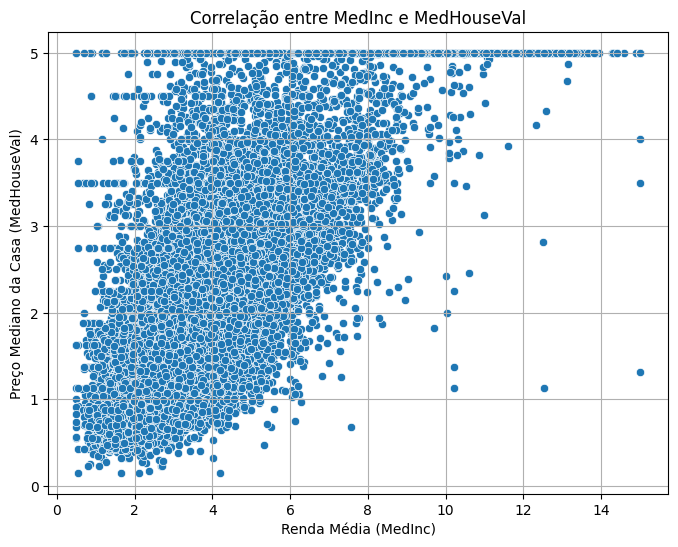

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)
plt.title('Correlação entre MedInc e MedHouseVal')
plt.xlabel('Renda Média (MedInc)')
plt.ylabel('Preço Mediano da Casa (MedHouseVal)')
plt.grid(True)
plt.show()

In [9]:
X_medinc = X[:, feature_names.index("MedInc")].reshape(-1,1)
X_medinc.shape

(20640, 1)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_medinc, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16512, 1) (16512,)
(4128, 1) (4128,)


In [11]:
def average_predictor(y):
  y_pred = np.ones_like(y) * np.mean(y)
  return y_pred

y_pred_average = average_predictor(y_train)
y_pred_average.shape

(16512,)

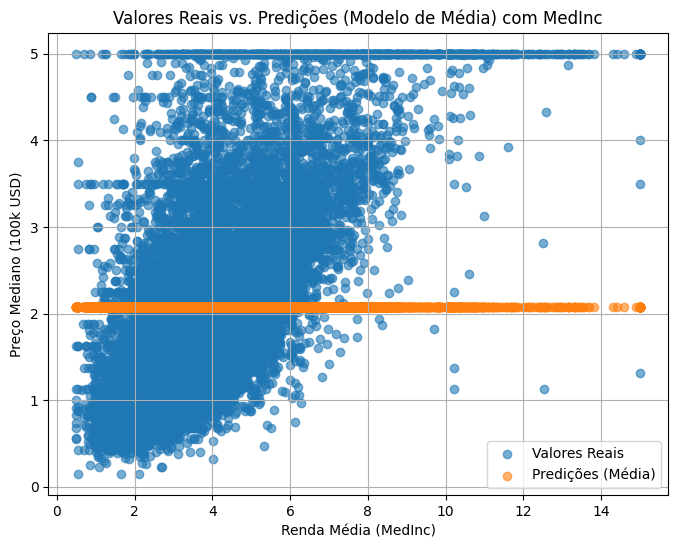

In [12]:
def plot_predictions(X_train, y_train, y_pred_average):
  plt.figure(figsize=(8, 6))
  plt.scatter(X_train, y_train, label="Valores Reais", alpha=0.6)
  plt.scatter(X_train, y_pred_average, label="Predições (Média)", alpha=0.6)
  plt.xlabel("Renda Média (MedInc)")
  plt.ylabel("Preço Mediano (100k USD)")
  plt.title("Valores Reais vs. Predições (Modelo de Média) com MedInc")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_predictions(X_train, y_train, y_pred_average)

In [14]:
print(y_pred_average[0])

2.071946937378876


In [13]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_train, y_pred_average)
print(f"Erro Quadrático Médio (MSE): {mse}")

Erro Quadrático Médio (MSE): 1.336778211789427


In [20]:
from sklearn.base import BaseEstimator, RegressorMixin

class AverageRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.mean = np.mean(y)
    def predict(self, X):
        y_pred = np.ones(shape=(X.shape[0],)) * self.mean
        return y_pred

average_regressor = AverageRegressor()
average_regressor.fit(X_train, y_train)
y_pred_average = average_regressor.predict(X_train)
mse = mean_squared_error(y_train, y_pred_average)
print(f"Erro Quadrático Médio (MSE): {mse}")

Erro Quadrático Médio (MSE): 1.336778211789427


## Regressão Linear Simples
- Uma variável explicativa $x \in \mathbb{R}$, alvo $y \in \mathbb{R}$.  
- Modelo:  
$$
\hat{y} = \beta_0 + \beta_1 x
$$  
- $\beta_0$: intercepto; $\beta_1$: inclinação.  

Erro Quadrático Médio (MSE): 5.193538044265922


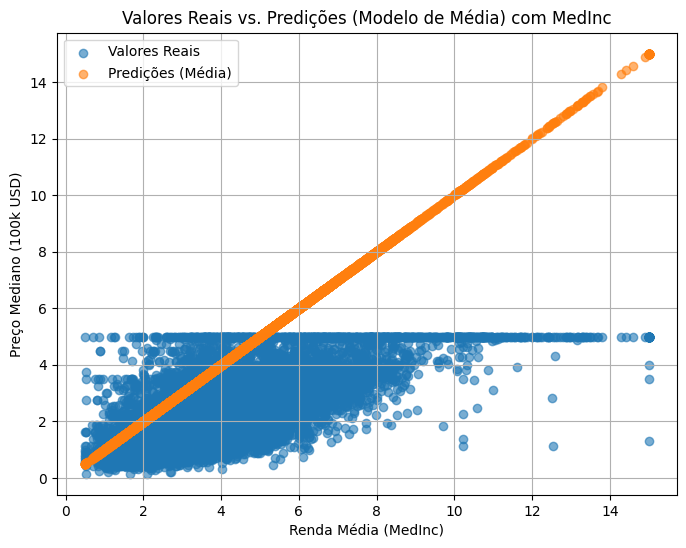

In [21]:
class LinearRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.intercept_ = 0
        self.coef_ = 1
        self
    def predict(self, X):
        y_pred = X * self.coef_ + self.intercept_
        return y_pred

lr = LinearRegressor()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_train)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train, y_train, y_pred_lr)

## Regressão Linear Múltipla (Escalar)
- Para $p$ features:  
$$
\hat{y}^{(i)} = \beta_0 + \beta_1 x_1^{(i)} + \dots + \beta_p x_p^{(i)}
$$  
- Vetor de parâmetros $\beta = (\beta_0, \dots, \beta_p)$.  

Erro Quadrático Médio (MSE): 5.193538044265922


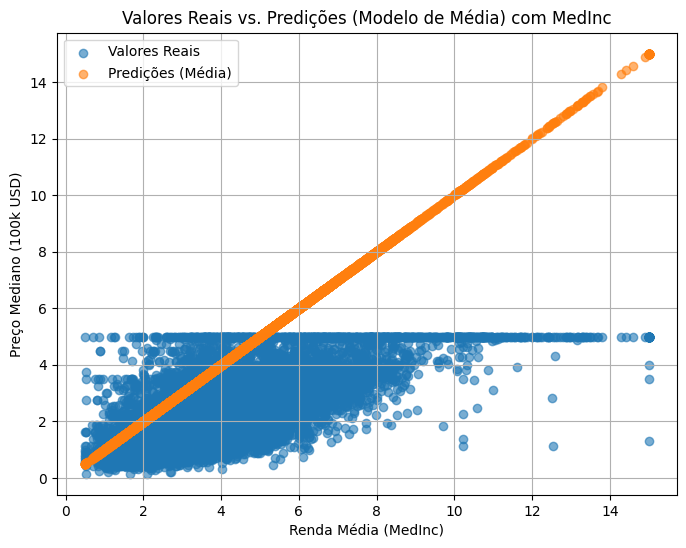

In [24]:
### Implementação matricial
class LinearRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.intercept_ = 0
        self.coefs_ = np.ones((X.shape[1],))
        self
    def predict(self, X):
        y_pred = X @ self.coefs_ + self.intercept_
        return y_pred

lr = LinearRegressor()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_train)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train[:,0:1], y_train, y_pred_lr)

Erro Quadrático Médio (MSE): 1.1855971490229726


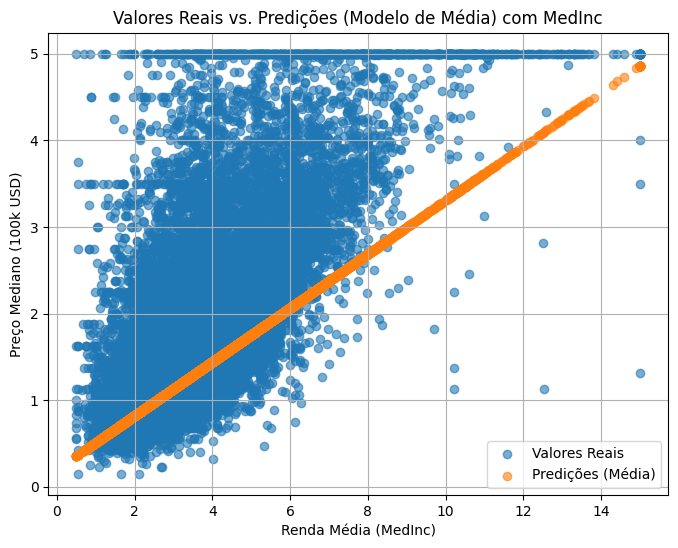

In [29]:
class LinearRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.intercept_ = np.random.rand()
        self.coefs_ = np.random.rand(X.shape[1])
        self
    def predict(self, X):
        y_pred = X @ self.coefs_ + self.intercept_
        return y_pred

lr = LinearRegressor()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_train)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train, y_train, y_pred_lr)

In [30]:
print(lr.intercept_, lr.coefs_)

0.19907194276643203 [0.31093475]


In [ ]:
lr.intercept_ = 0.15
lr.coefs_[0] = 0.5

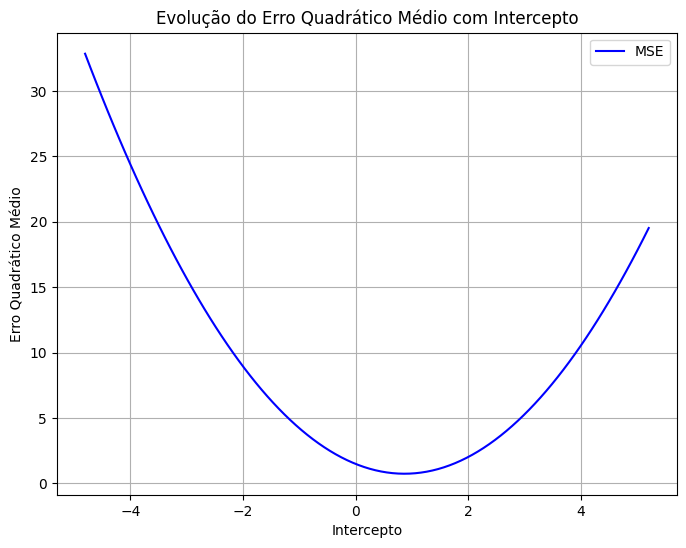

In [31]:
def plot_mse_by_intercept(model, X, y):
  intercept = model.intercept_
  i_min = intercept - 5
  i_max = intercept + 5
  mse_list = []
  for i in np.linspace(i_min, i_max, 100):
    model.intercept_ = i
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
  plt.figure(figsize=(8, 6))
  plt.plot(np.linspace(i_min, i_max, 100), mse_list
           , label="MSE", color="blue")
  plt.xlabel("Intercepto")
  plt.ylabel("Erro Quadrático Médio")
  plt.title("Evolução do Erro Quadrático Médio com Intercepto")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_mse_by_intercept(lr, X_train, y_train)

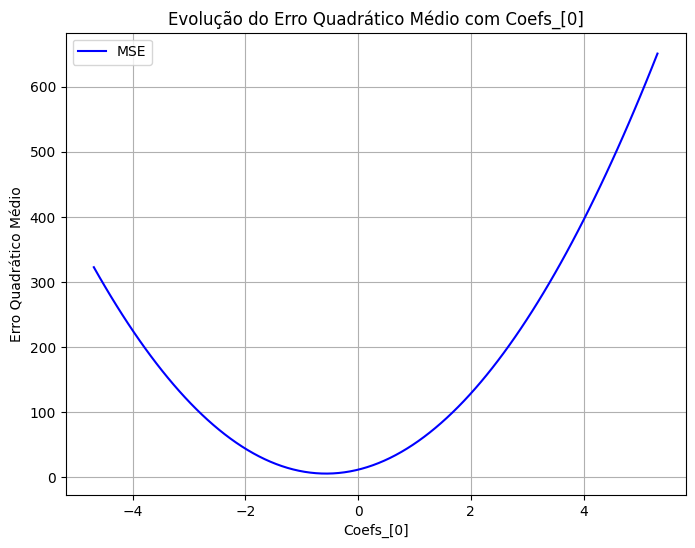

In [32]:
def plot_mse_by_coef0(model, X, y):
  coef0 = model.coefs_[0]
  i_min = coef0 - 5
  i_max = coef0 + 5
  mse_list = []
  for i in np.linspace(i_min, i_max, 100):
    model.coefs_[0] = i
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)
  plt.figure(figsize=(8, 6))
  plt.plot(np.linspace(i_min, i_max, 100), mse_list
           , label="MSE", color="blue")
  plt.xlabel("Coefs_[0]")
  plt.ylabel("Erro Quadrático Médio")
  plt.title("Evolução do Erro Quadrático Médio com Coefs_[0]")
  plt.legend()
  plt.grid(True)
  plt.show()

plot_mse_by_coef0(lr, X_train, y_train)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Erro Quadrático Médio (MSE): 0.6991447170306765


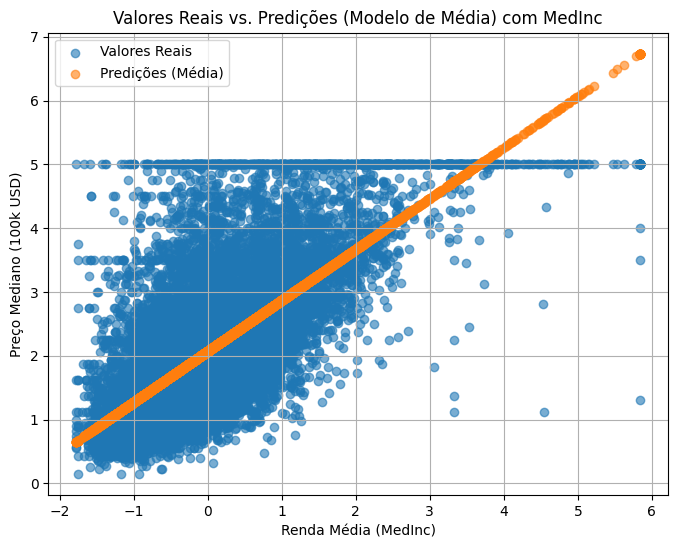

In [45]:
## Stochastic Gradient Descent
class LinearRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.0001, num_iterations=30):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
    def fit(self, X, y):
        self.intercept_ = np.random.rand()
        self.coefs_ = np.random.rand(X.shape[1])
        for _ in range(self.num_iterations):
            y_pred = X @ self.coefs_ + self.intercept_
            error = y - y_pred
            # print(f"coefs_:{self.coefs_}, \
            # intercept_:{self.intercept_}, \
            # mse:{mean_squared_error(y, y_pred)}")
            self.coefs_ += self.learning_rate * X.T @ error
            self.intercept_ += self.learning_rate * np.sum(error)
        self
    def predict(self, X):
        y_pred = X @ self.coefs_ + self.intercept_
        return y_pred


lr = LinearRegressor()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train_scaled, y_train, y_pred_lr)

Erro Quadrático Médio (MSE): 0.6991447170182824


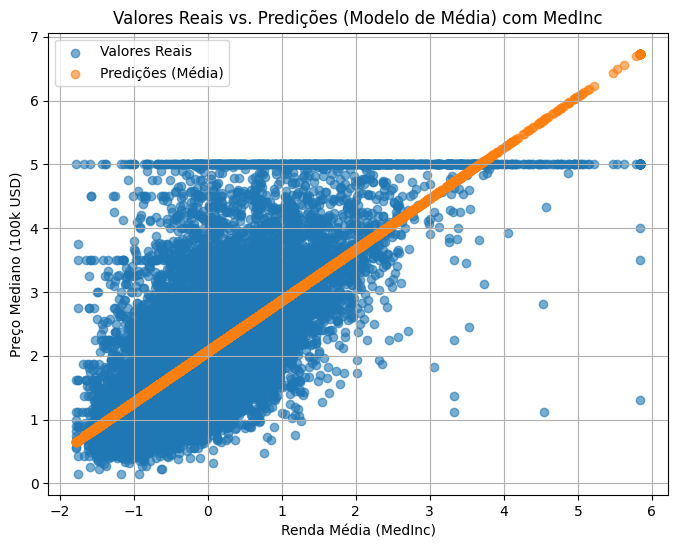

In [52]:
### Moore-Penrose Pseudo Inverse
class LinearRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.intercept_ = np.linalg.pinv(np.ones((X.shape[0],1))) @ y
        self.coefs_ = np.linalg.pinv(X) @ y
        self
    def predict(self, X):
        y_pred = X @ self.coefs_ + self.intercept_
        return y_pred


lr = LinearRegressor()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train_scaled, y_train, y_pred_lr)

Erro Quadrático Médio (MSE): 0.6991447170182824


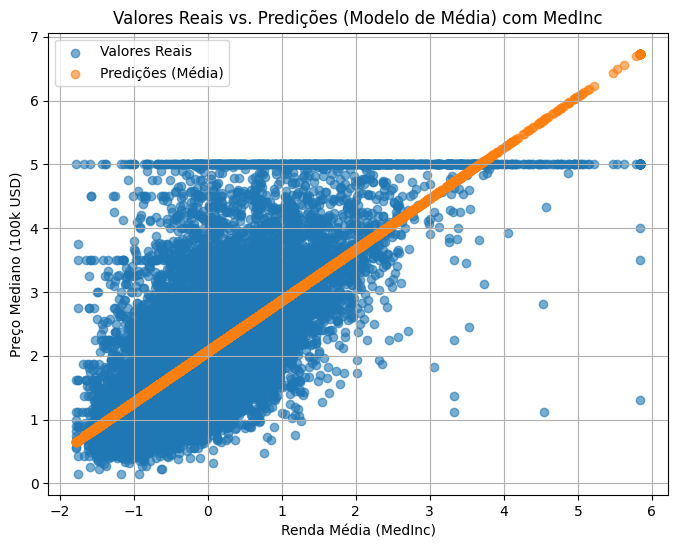

In [56]:
### Pseudo Inverse with bias

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class LinearRegressor(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        Xb = include_bias(X)
        self.w = np.linalg.pinv(Xb) @ y
        self
    def predict(self, X):
        Xb = include_bias(X)
        y_pred = Xb @ self.w
        return y_pred


lr = LinearRegressor()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train_scaled, y_train, y_pred_lr)

Erro Quadrático Médio (MSE): 0.6991447170311856


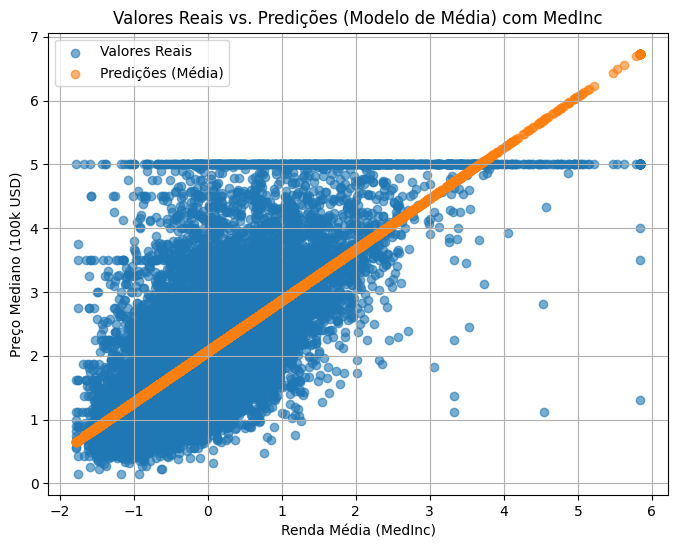

In [58]:
### SGD with bias

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class LinearRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, learning_rate=0.0001, num_iterations=30):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
    def fit(self, X, y):
        self.w = np.random.rand(X.shape[1]+1)
        Xb = include_bias(X)
        for _ in range(self.num_iterations):
            y_pred = Xb @ self.w
            error = y - y_pred
            self.w += self.learning_rate * Xb.T @ error
        self
    def predict(self, X):
        Xb = include_bias(X)
        y_pred = Xb @ self.w
        return y_pred


lr = LinearRegressor()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train_scaled, y_train, y_pred_lr)

Erro Quadrático Médio (MSE): 0.6991447170182823


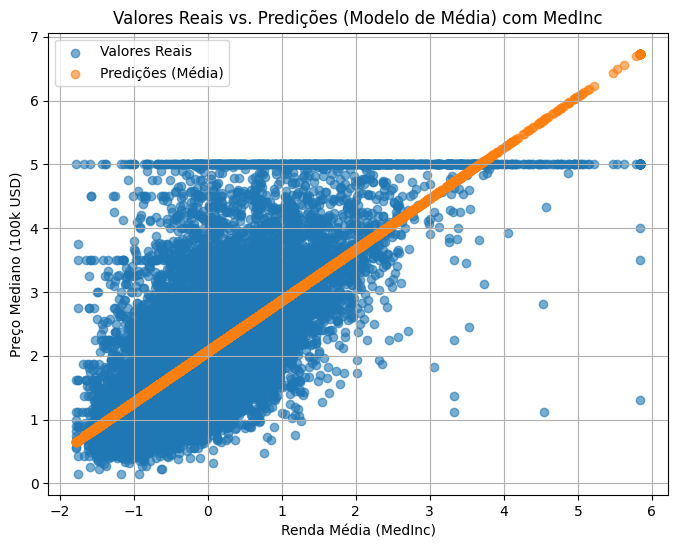

In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")
plot_predictions(X_train_scaled, y_train, y_pred_lr)

### Com todas as características

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred_lr)
print(f"Erro Quadrático Médio (MSE): {mse}")

Erro Quadrático Médio (MSE): 0.5179331255246699


In [63]:
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE) no dataset de teste: {mse}")


Erro Quadrático Médio (MSE) no dataset de teste: 0.5558915986952442
